## Data Modeling

In this section, raw sales data is transformed into analytical features such as
discounted price, revenue, and profit to support business decision-making.


IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10,6)

In [2]:
#LOAD DATASET

In [3]:
df = pd.read_csv("raw_sales_data.csv",encoding="latin1")

In [4]:
#UNDERSTAND DATA STRUCTURE

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df.shape

(9994, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [8]:
df.describe(include='all')

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994,9994,9994,9994,9994,9994,9994,...,9994.000000,9994,9994,9994,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
unique,NaN,5009,1237,1334,4,793,793,3,1,531,...,NaN,4,1862,3,17,1850,NaN,NaN,NaN,NaN
top,NaN,CA-2017-100111,9/5/2016,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,...,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,NaN
freq,NaN,14,38,35,5968,37,37,5191,9994,915,...,NaN,3203,19,6026,1523,48,NaN,NaN,NaN,NaN
mean,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,55190.379428,NaN,NaN,NaN,NaN,NaN,229.858001,3.789574,0.156203,28.656896
std,2885.163629,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,32063.693350,NaN,NaN,NaN,NaN,NaN,623.245101,2.225110,0.206452,234.260108
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23223.000000,NaN,NaN,NaN,NaN,NaN,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,56430.500000,NaN,NaN,NaN,NaN,NaN,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,90008.000000,NaN,NaN,NaN,NaN,NaN,209.940000,5.000000,0.200000,29.364000


In [9]:
#DATA CLEANING

In [10]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [11]:
df.columns=df.columns.str.lower()
df.columns=df.columns.str.replace(' ','_')

In [12]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')

In [13]:
#CREATE BUSINESS COLUMNS

In [14]:
# Revenue is already Sales
# In this dataset, 'Sales' already represents final revenue after discount
df['revenue'] = df['sales']

# Cost calculation
# Profit = Revenue - Cost
# Therefore Cost = Revenue - Profit
df['cost'] = df['revenue'] - df['profit']

df[['revenue','discount','quantity','profit','cost']].head()


,revenue,discount,quantity,profit,cost
0,261.9600,0.00,2,41.9136,220.0464
1,731.9400,0.00,3,219.5820,512.3580
2,14.6200,0.00,2,6.8714,7.7486
3,957.5775,0.45,5,-383.0310,1340.6085
4,22.3680,0.20,2,2.5164,19.8516


In [15]:
#SAVE CLEANED DATA (FOR SQL & POWER BI)

In [17]:
df.to_csv("raw_sales_data_final.csv", index=False)
print("Final dataset saved successfully!")


Final dataset saved successfully!


In [17]:
#SDATA ANALYSIS SECTION

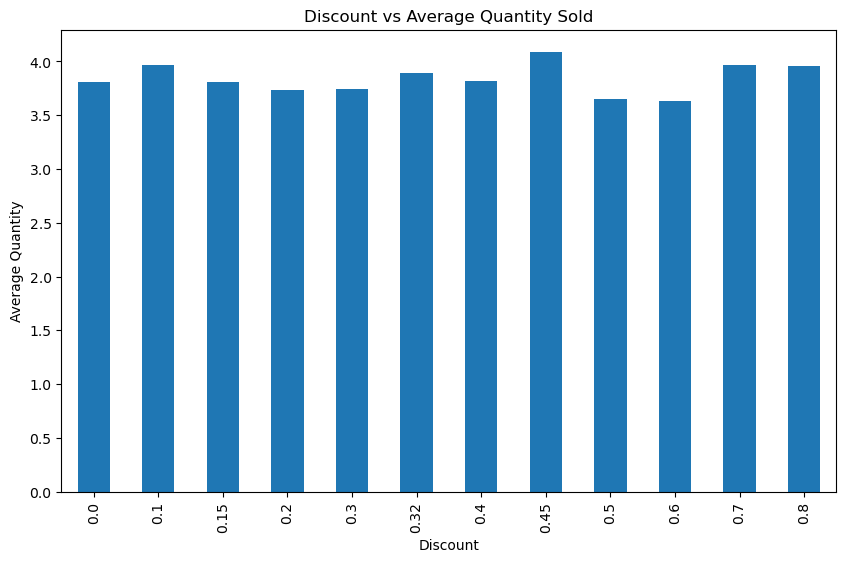

In [18]:
#DISCOUNT VS QUANTITY SOLD
discount_quantity = df.groupby('discount')['quantity'].mean()

discount_quantity.plot(kind='bar')
plt.title("Discount vs Average Quantity Sold")
plt.xlabel("Discount")
plt.ylabel("Average Quantity")
plt.show()

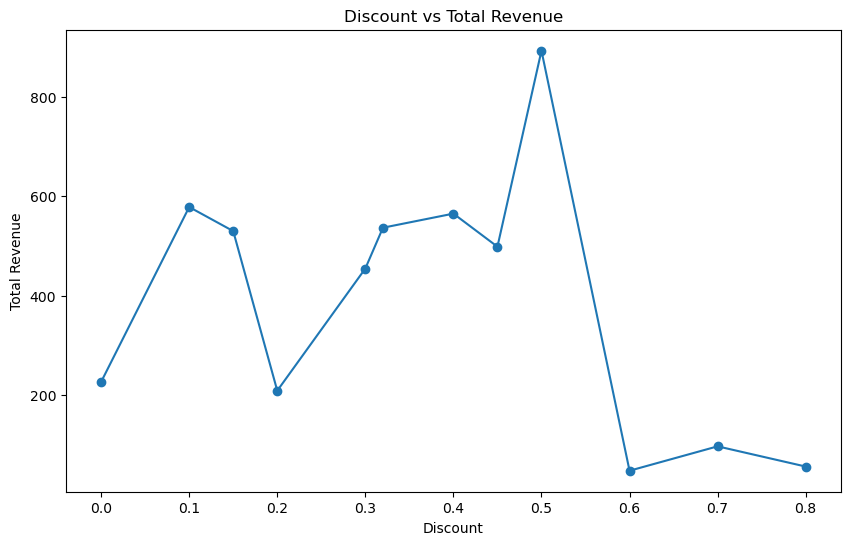

In [19]:
#DISCOUNT VS REVENUE
discount_revenue = df.groupby('discount')['revenue'].mean()
discount_revenue.plot(kind='line', marker='o')
plt.title("Discount vs Total Revenue")
plt.xlabel("Discount")
plt.ylabel("Total Revenue")
plt.show()


In [39]:
print("REVENUE ANALYSIS INSIGHTS:")
print("1. Revenue increases at small discounts (around 10%).")
print("2. Maximum revenue occurs at 50% discount.")
print("3. However, high revenue at 50% does not translate into profit.")
print("4. Revenue declines sharply beyond 60% discount.")
print("5. Business should focus on profit optimization rather than revenue maximization.")

REVENUE ANALYSIS INSIGHTS:
1. Revenue increases at small discounts (around 10%).
2. Maximum revenue occurs at 50% discount.
3. However, high revenue at 50% does not translate into profit.
4. Revenue declines sharply beyond 60% discount.
5. Business should focus on profit optimization rather than revenue maximization.


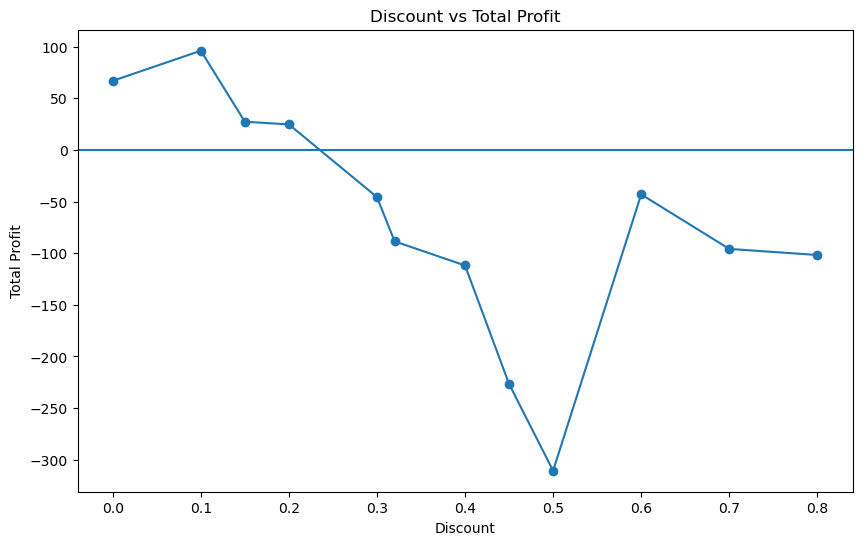

In [20]:
#DISCOUNT VS PROFIT
discount_profit = df.groupby('discount')['profit'].mean()

discount_profit.plot(kind='line', marker='o')
plt.axhline(0)
plt.title("Discount vs Total Profit")
plt.xlabel("Discount")
plt.ylabel("Total Profit")
plt.show()


In [38]:
print("DISCOUNT STRATEGY INSIGHTS:")
print("1. Maximum profit is achieved at 10% discount.")
print("2. Discounts above 20% significantly reduce profitability.")
print("3. 40%–50% discount range results in heavy losses.")
print("4. Aggressive discounting strategy is not sustainable.")
print("5. Business should focus on low discount strategy (0–10%).")

DISCOUNT STRATEGY INSIGHTS:
1. Maximum profit is achieved at 10% discount.
2. Discounts above 20% significantly reduce profitability.
3. 40%–50% discount range results in heavy losses.
4. Aggressive discounting strategy is not sustainable.
5. Business should focus on low discount strategy (0–10%).


<Axes: >

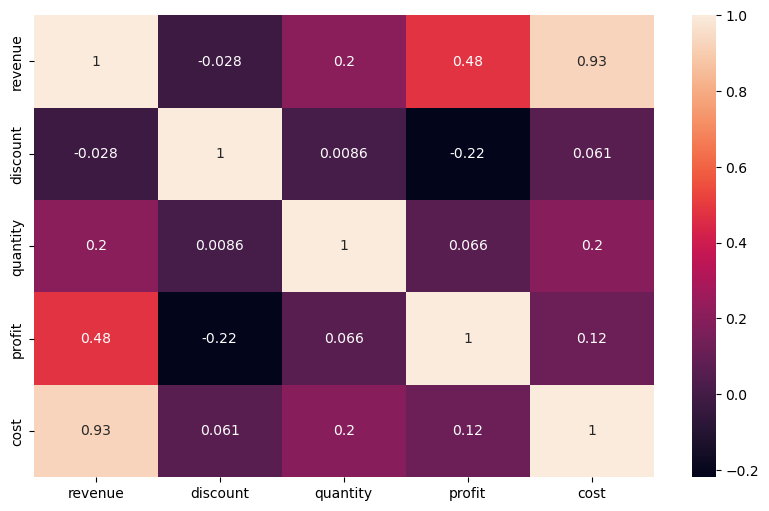

In [21]:
df[['revenue','discount','quantity','profit','cost']].corr()
import seaborn as sns
sns.heatmap(df[['revenue','discount','quantity','profit','cost']].corr(), annot=True)


In [37]:
print("CORRELATION ANALYSIS INSIGHTS:")
print("1. Revenue and cost have very strong positive correlation (0.93), meaning high-cost products generate higher revenue.")
print("2. Discount has negative correlation with profit (-0.22), confirming that higher discounts reduce profitability.")
print("3. Discount has almost no correlation with quantity (0.008), indicating customers are not highly price-sensitive.")
print("4. Discount does not significantly increase revenue (-0.028 correlation).")
print("5. Increasing revenue alone does not guarantee proportional profit growth (0.48 correlation).")

CORRELATION ANALYSIS INSIGHTS:
1. Revenue and cost have very strong positive correlation (0.93), meaning high-cost products generate higher revenue.
2. Discount has negative correlation with profit (-0.22), confirming that higher discounts reduce profitability.
3. Discount has almost no correlation with quantity (0.008), indicating customers are not highly price-sensitive.
4. Discount does not significantly increase revenue (-0.028 correlation).
5. Increasing revenue alone does not guarantee proportional profit growth (0.48 correlation).


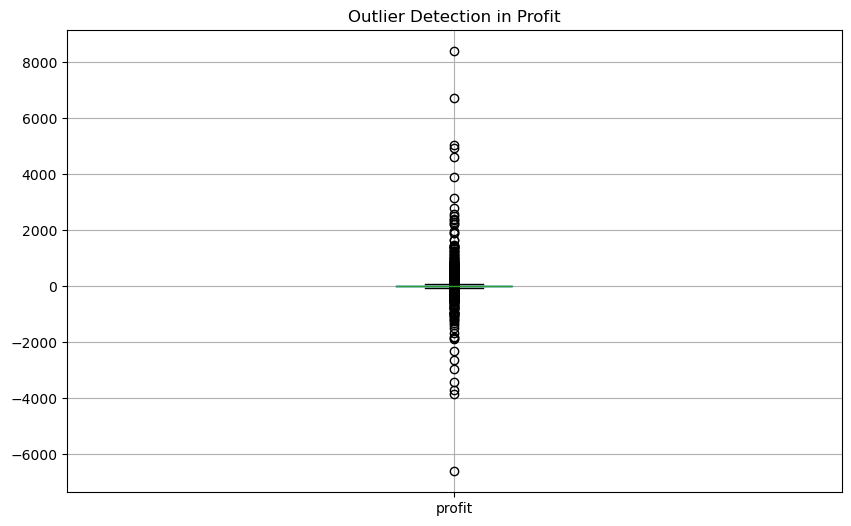

In [22]:
df.boxplot(column='profit')
plt.title("Outlier Detection in Profit")
plt.show()


In [23]:
#FIND OPTIMAL DISCOUNT VALUE
optimal_discount = discount_profit.idxmax()
max_profit = discount_profit.max()

optimal_discount, max_profit


(np.float64(0.1), 96.05507446808511)

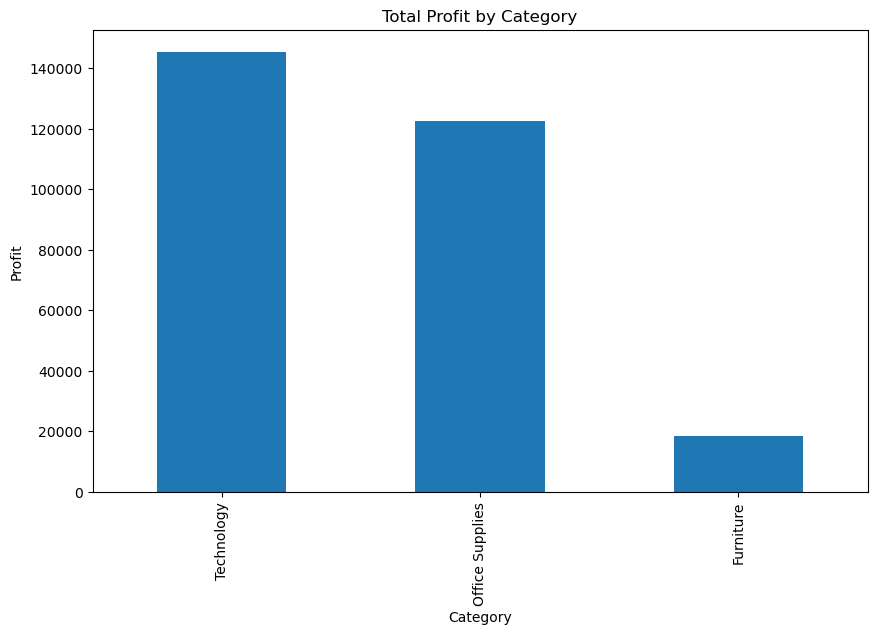

In [24]:
#CATEGORY-WISE PROFIT ANALYSIS
category_profit = df.groupby('category')['profit'].sum().sort_values(ascending=False)

category_profit.plot(kind='bar')
plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()


In [36]:
print("CATEGORY-WISE BUSINESS INSIGHTS:")
print("1. Technology is the highest profit-generating category and drives overall business profitability.")
print("2. Office Supplies contributes strong and stable profits.")
print("3. Furniture generates significantly lower profit, indicating need for pricing or discount optimization.")
print("4. Business should focus more on Technology while improving strategy for Furniture.")

CATEGORY-WISE BUSINESS INSIGHTS:
1. Technology is the highest profit-generating category and drives overall business profitability.
2. Office Supplies contributes strong and stable profits.
3. Furniture generates significantly lower profit, indicating need for pricing or discount optimization.
4. Business should focus more on Technology while improving strategy for Furniture.


In [25]:
#PRODUCTS THAT SHOULD NOT BE DISCOUNTED
loss_products = df[(df['discount'] > 0) & (df['profit'] < 0)]

loss_products[['product_name','discount','profit']].head(10)


,product_name,discount,profit
3,Bretford CR4500 Series Slim Rectangular Table,0.45,-383.0310
14,Holmes Replacement Filter for HEPA Air Cleaner...,0.80,-123.8580
15,Storex DuraTech Recycled Plastic Frosted Binders,0.80,-3.8160
23,"Global Deluxe Stacking Chair, Gray",0.30,-1.0196
27,"Riverside Palais Royal Lawyers Bookcase, Royal...",0.50,-1665.0522
28,Avery Recycled Flexi-View Covers for Binding S...,0.70,-7.0532
32,"Acco Pressboard Covers with Storage Hooks, 14 ...",0.70,-5.7150
36,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",0.60,-147.9630
38,"Atlantic Metals Mobile 3-Shelf Bookcases, Cust...",0.32,-46.9764
39,"Global Fabric Manager's Chair, Dark Gray",0.30,-15.1470


In [26]:
#PRICE-SENSITIVE VS PREMIUM PRODUCTS
price_sensitivity = df.groupby('product_name').agg({
    'discount': 'mean',
    'quantity': 'sum',
    'profit': 'sum'
}).reset_index()

price_sensitivity.sort_values(by='profit', ascending=False).head(10)


,product_name,discount,quantity,profit
404,Canon imageCLASS 2200 Advanced Copier,0.120000,20,25199.9280
650,Fellowes PB500 Electric Punch Plastic Comb Bin...,0.240000,31,7753.0390
805,Hewlett Packard LaserJet 3310 Copier,0.200000,38,6983.8836
400,Canon PC1060 Personal Laser Copier,0.150000,19,4570.9347
787,HP Designjet T520 Inkjet Large Format Printer ...,0.166667,12,4094.9766
165,Ativa V4110MDD Micro-Cut Shredder,0.000000,11,3772.9461
19,"3D Systems Cube Printer, 2nd Generation, Magenta",0.000000,11,3717.9714
1276,Plantronics Savi W720 Multi-Device Wireless He...,0.057143,24,3696.2820
895,Ibico EPK-21 Electric Binding System,0.333333,13,3345.2823
1840,Zebra ZM400 Thermal Label Printer,0.000000,6,3343.5360


In [29]:
print(discount_profit.sort_values(ascending=False))

discount
0.10     96.055074
0.00     66.900292
0.15     27.288298
0.20     24.702572
0.60    -43.077212
0.30    -45.679636
0.32    -88.560656
0.70    -95.874060
0.80   -101.796797
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
Name: profit, dtype: float64


In [30]:
optimal_range = range_profit[range_profit > 0].index
print("Profitable discount ranges:", list(optimal_range))

Profitable discount ranges: ['0-10%', '10-20%']


C:\Users\HP\AppData\Local\Temp\ipykernel_7804\4118052681.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  range_profit = df.groupby('Discount_Range')['profit'].mean()


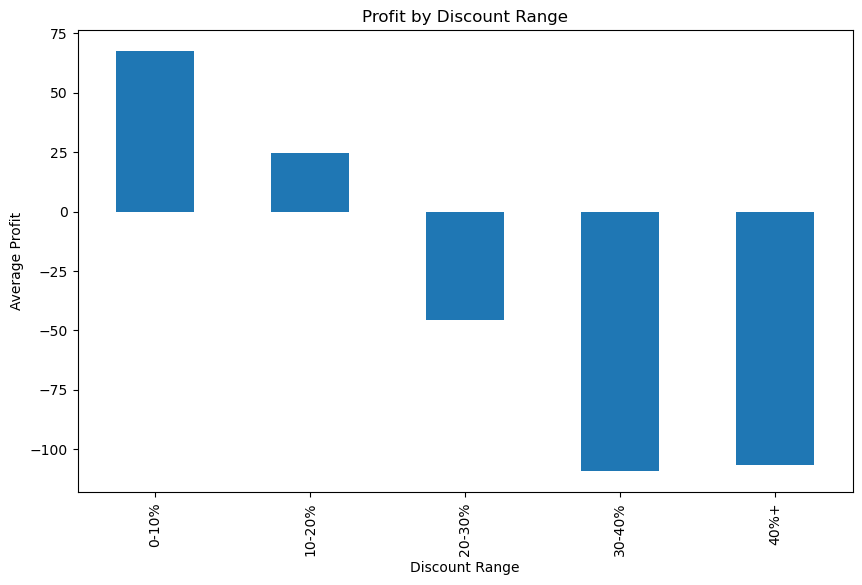

In [27]:
#DISCOUNT RANGE ANALYSIS (ADVANCED & IMPRESSIVE)
df['Discount_Range'] = pd.cut(
    df['discount'],
    bins=[-0.01,0.1,0.2,0.3,0.4,1],
    labels=['0-10%','10-20%','20-30%','30-40%','40%+']
)

range_profit = df.groupby('Discount_Range')['profit'].mean()

range_profit.plot(kind='bar')
plt.title("Profit by Discount Range")
plt.xlabel("Discount Range")
plt.ylabel("Average Profit")
plt.show()


In [35]:
#FINAL BUSINESS INSIGHTS
print("BUSINESS INSIGHTS:")
print(f"1. Optimal discount range for maximum profit: {optimal_discount}")
print("2. Discount ranges above 20% show negative average profit, indicating reduced profitability.")
print("3. Profit declines significantly beyond the 20% discount threshold.")
print("4. Small targeted discounts perform better than heavy discounts.")


BUSINESS INSIGHTS:
1. Optimal discount range for maximum profit: 0.1
2. Discount ranges above 20% show negative average profit, indicating reduced profitability.
3. Profit declines significantly beyond the 20% discount threshold.
4. Small targeted discounts perform better than heavy discounts.
